In [60]:
import matplotlib.pyplot as plt 
import random
import math
import numpy as np
from copy import copy
import os

# Assignment 2 - Reinforcement Learning, Part 1

## Reinforcement Learning, Part 1: Agents, States, and Rewards  

Here we will show the simplest form of RL: An agent going through a simple environment with a deterministic succession of states.

## The environment

The environment represents a prototypical conditioning paradigm. It is made of three states, which represent an initial  cue, a delay, and a reward. This captures a simple experiment such as the case in which a primate is given reward (juice) after a blue light is presented.

An environment is defined by two functions, the state transition matrix $P(s,a,s')$ and a reward transition matrix $R(s,a,s')$. In this simple case, the agent does not act, it is simply observing the environment. So, we can define $P(s,s')$ and $R(s,s')$ without any reference to any action $a$. Furthermore, because the environment is deterministic, we can represent both $P(s,s')$ and $R(s,s')$ as _tables_.

#### Implementation in Python

In the code below, the Environment's state and reward transitions are implemented as _dictionaries_, that is, special structures that associate one object (the _key_) with another (the _value_). This is a very convenient format for a simple environment in which all events follow deterministically. The `STATE_TRANSITIONS` dictionary links each state with the state that follows. The `REWARD_TRANSITIONS` dictionary links each state with its associated reward.  The null object `None` marks the end of a trial.

When the environment undergoes a transition, the agent receives a new state-reward pair, which, in Python, will be represented as a tuple `(new_state, new_reward)`.

In [61]:
class Environment:
    """A simple environment"""
    STATE_TRANSITIONS = {"cue" : "wait",
                         "wait" : "juice",
                         "juice" : None}
    
    REWARD_TRANSITIONS = {"cue" : 0,
                          "wait" : 0,
                          "juice" : 0,
                          None : 1}
    
    def __init__(self):
        """Initializes the environment"""
        # An environment class always keeps track of the current state we are in.
        # We always begin with the state 'cue' (the beginning of a trial)
        self.state = "cue"
    
    
    def transition(self):
        """Transitions, and returns the state-reward pair"""
        state = self.state  # The current state
        
        if state.startswith("start"):
            new_state = "cue"
        else:
            new_state = Environment.STATE_TRANSITIONS[state]
        new_reward = Environment.REWARD_TRANSITIONS[new_state]
        
        # Let's update the current state before 
        self.state = new_state
        
        # The agent receives the new state and reward. 
        return (new_state, new_reward)

#### Testing the Environment

Let's test how the environment works

In [62]:
e = Environment()
print("State 1: '%s'" % (e.state,))

# First transition: Cue -> Wait
res = e.transition()
print("State 2: '%s', Reward = %s" % res)

# Second transition: Wait -> Juice
res = e.transition()
print("State 3: '%s', Reward = %s" % res)

# Final transition: Juice -> 'None'
res = e.transition()
print("After state 3: '%s'" % (e.state,))

State 1: 'cue'
State 2: 'wait', Reward = 0
State 3: 'juice', Reward = 0
After state 3: 'None'


## The Agent

Now, let's create a simple agent that just observes states and estimates their values by creating a $V$-table. Because the number of states is so small, the $V$-table can be initialized right away, with all the states being zero. 

The $V$-Agent learns the value of states using TD-learning. Every time the agent observes a new state, it updates the associated value of the previous state using the TD-learning equation:

$V(s_t) \leftarrow V(s_t) + \alpha [ r_t + \gamma V(s_{t+1}) - V(s_t)]$

#### Implementation in Python

The agent is an object with two internal parameters, `alpha` and `gamma` (which record to the $\alpha$ and $\gamma$ values of the TD-learning equation), and a dictionary that records the $V$-values associated with every state (The $V$ table). The agent has a single method, `learn`, that implements the TD-learning equation.

In [63]:
class TDAgent():
    """An agent that passively observes states"""
    def __init__(self, gamma=0.9, alpha=0.1):
        "Initializes an agent with default parameters and zero values in the V table"
        self.V = {"cue" : 0,
                  "wait" : 0,
                  "juice" : 0,
                  None : 0}
        
        self.RPE = {"cue" : 0,
                    "wait" : 0,
                    "juice" : 0,
                     None : 0}
        self.gamma = gamma
        
        self.alpha = alpha
        
    # This method implements TD-learning
    #
    def TD_learn(self, state1, reward2, state2):
        """Learns using TD-learning"""
        V1 = self.V[state1] if state1 in self.V.keys() else 0
        V2 = self.V[state2]
        g = self.gamma
        a = self.alpha
        
        # Calculate RPE and new estimate of V1
        rpe = reward2 + g * V2 - V1
        V1 = V1 + a * rpe
        
        # Save the RPEs for demo
        if state2 is None:
            self.RPE["juice"] = rpe
        else:
            self.RPE[state2] = rpe
        
        # Update the internal value of V1
        self.V[state1] = V1

## Interactions between agent and environment
Now, we need to define how to run a trial.

In [64]:
def rl_loop(environment, agent):
    "The interaction cycle between an agent and its environment"
    while environment.state is not None:
        state = environment.state
        #if state.startswith("start"):
        #    reward = 0
        #else:
        #    reward = environment.REWARD_TRANSITIONS[state]
        
        # This is the moment in which we learn!
        transition = environment.transition()
        new_state = None
        if transition is not None:
            new_state = transition[0]

        new_reward = environment.REWARD_TRANSITIONS[new_state]
        agent.TD_learn(state, new_reward, new_state)

        
def run_trials(environment, agent, n):
    "Run multiple simulations within an environment"
    for j in range(n):
        environment.state = "start%d" % (random.randint(0, 1000))
        rl_loop(environment, agent) 

## Testing the system

To test the system, we need to create a function that visualizes a $V$-table. The following function takes an agent's dictionary of state-value associations and visualizes them in a bar graph. For simplicity, the state `None` is not shown.

In [65]:
# This is a simple function to visualize the agent's V-table
def plot_v_table(Vtable, axes, title="V table"):
    """Visualizes the V-table"""
    states = ["cue", "wait", "juice"]
    values = [Vtable[x] for x in states]

    axes.axis([-0.5, 2.5, -1.1, 1.1])
    axes.set_xticks([0, 1, 2])
    axes.set_xticklabels(["cue", "wait", "juice"])
    axes.bar([0, 1, 2], values)
    axes.set_title(title)
    
def plot_rpes(rpes, axes, title="RPE"):
    """Visualizes the RPEs"""
    states = ["cue", "wait", "juice"]
    values = [rpes[x] for x in states]
    
    axes.axis([-0.5, 2.5, -1.1, 1.1])
    axes.set_xticks([0, 1, 2])
    axes.set_xticklabels(["cue", "wait", "juice"])
    axes.bar([0, 1, 2], values)
    axes.set_title(title)

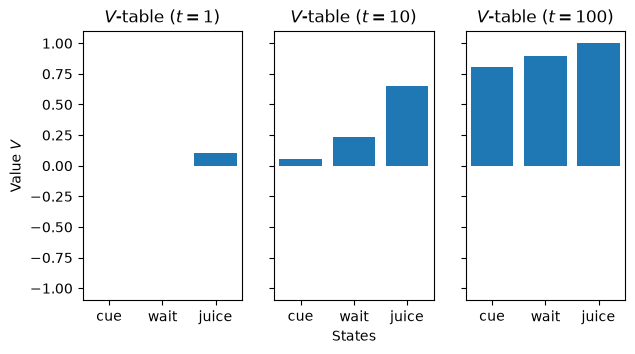

In [66]:
states = ["cue", "wait", "juice", None]

a = TDAgent()
e = Environment()

fig, axs = plt.subplots(1,3, figsize=(7,3.5), sharey=True)

for ax in axs.flat:
    ax.label_outer()

axs[0].set_ylabel(r"Value $V$")
axs[1].set_xlabel("States")    

run_trials(e, a, 1)
plot_v_table(a.V, axs[0], r"$V$-table ($t=1$)")

run_trials(e, a, 9)
plot_v_table(a.V, axs[1], r"$V$-table ($t=10$)")

run_trials(e, a, 90)
plot_v_table(a.V, axs[2], r"$V$-table ($t=100$)")


### Exercise 1a: Explain V-Table (1 pt)

Briefly, explain the previous V-table. How does the V-table develop over time, and why?

*Answer (1a):* The V-table initially starts off with all of the values at 0, this is because there is no information yet. As the trials progress, The state with the reward ("juice") is prioritised when updating the value. In the first V-table (t=1), there has only been 1 trial, and the reward was given at "juice", and so the value V of "juice" was increased only. As the trials progress, the TD-learning model discovers that if you get to the "wait" state, you are one state away from the "juice" state where you get rewarded, so the value of that begins increasing as well but less so than "juice" because of the gamma value. The same then happens to the "cue" state, it gets a decreased value of "wait" assigned to it according to the formula. 

### Exercise 1b: Explaining the RPE (2 pts)

Now, plot both the V-Table and the RPE, similarly to how we have done it for the previous task after 1, 10, and 100 trials. Briefly describe how the RPE develops in relation to the V-Table and explain why and how they relate.

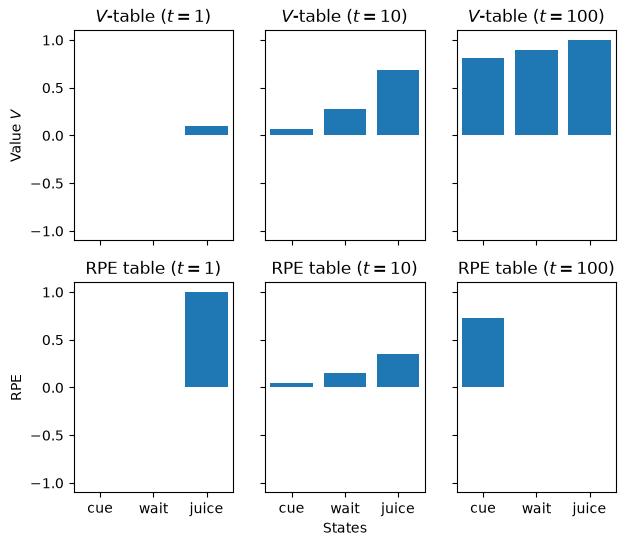

In [67]:
# YOUR CODE HERE
states = ["cue", "wait", "juice", None]

a = TDAgent()
e = Environment()

fig, axs = plt.subplots(2, 3, figsize=(7, 6), sharey='row')

for ax in axs.flat:
    ax.label_outer()

axs[0, 0].set_ylabel(r"Value $V$")
axs[1, 0].set_ylabel("RPE")
axs[1, 1].set_xlabel("States")

run_trials(e, a, 1)
plot_v_table(a.V, axs[0, 0], r"$V$-table ($t=1$)")
plot_rpes(a.RPE, axs[1, 0], r"RPE table ($t=1$)")

run_trials(e, a, 10)
plot_v_table(a.V, axs[0, 1], r"$V$-table ($t=10$)")
plot_rpes(a.RPE, axs[1, 1], r"RPE table ($t=10$)")

run_trials(e, a, 100)
plot_v_table(a.V, axs[0, 2], r"$V$-table ($t=100$)")
plot_rpes(a.RPE, axs[1, 2], r"RPE table ($t=100$)")


*Answer (1b):* When the trial is ran only once, the RPE checks what the difference between the expected and achieved reward values are, with "cue" and "wait", there is no difference and therefore there is no error. However, with "juice", the expected is initially 0, and the reward is 1, so there is a difference that makes the RPE jump to 1. I believe that when the trial is run 10 times the values are still adjusting and since the expected reward for "cue" and wait" are still low and close to 0, there isnt much RPE there, and the value for "juice" is increasing to match the reward as well so the RPE lowers. In the end, after a 100 runs, the expected reward matches for "juice" so the RPE zeros out, while the value for "cue" is increased although there are no rewards 1 step before or after or at "cue", so the expected reward is still 0 while the value is high because it is actually 2 steps away from the goal, but this still increases the RPE. 

### Exercise 1c: The missing juice (2 pts)

Week 2 B (slide 18) describes a third condition. Once the association has been learned, the cue is presented as usual but the reward is then withheld. Reproduce that condition here.

Train a fresh agent for 100 trials as before, then run one further trial with the reward withheld, and plot that agent's $V$-table and its RPEs side by side. The cell below already contains the lines that switch the reward off and back on again; write your training and plotting code around them and leave the `try`/`finally` intact.

Briefly describe what happens to the RPE at each of the three states when an expected reward fails to arrive, and relate it to the values the $V$-table still holds.

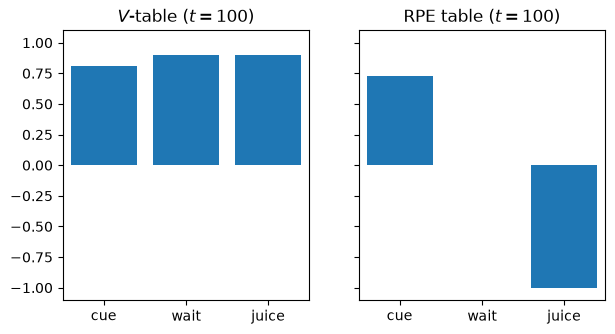

In [68]:
# YOUR CODE HERE
# Train a fresh agent for 100 trials.
a = TDAgent()
e = Environment()

run_trials(e, a, 100)

# Withhold the reward for exactly one trial. The try/finally is not decoration:
# REWARD_TRANSITIONS belongs to the class, not to your agent, so if this cell
# stops between the two lines the reward stays switched off for the rest of the
# kernel session and every earlier figure in Part 1 silently changes.
Environment.REWARD_TRANSITIONS[None] = 0
try:
    # YOUR CODE HERE
    # Run one further trial.
    run_trials(e, a, 1)
finally:
    Environment.REWARD_TRANSITIONS[None] = 1

# YOUR CODE HERE
# Plot the V-table and the RPEs side by side.

fig, axs = plt.subplots(1, 2, figsize=(7, 3.5), sharey='row')

for ax in axs.flat:
    ax.label_outer()
plot_v_table(a.V, axs[0], r"$V$-table ($t=100$)")
plot_rpes(a.RPE, axs[1], r"RPE table ($t=100$)")



*Answer (1c):* The V-value is slowly updated with each trial, thats why we dont have a big difference between the v-value table here and in 1b. The values are still consistent but with a slight decrease in the value for "juice". However, the RPE values change instantly after each trial. The values we would have seen on the 100th trial (without the final reward withholding trial) would have looked exactly the same as the one in 1b. This is the reason for this drastic difference in RPE tables between 1b and 1c. Since a reward was expected and not given, the RPE value instantly jumped from 0 to -1 between trials 100 and 101.

## Reinforcement Learning, Part 2: Agents That Act in an Environment

Here we are going to implement a RL agent interacting with a simple environment. In this case, our agent would be a simulated RL mouse, and the environment a 2D maze.

## Defining the Environment

To define the environment, we need to define the set of possible states $S = {s_1, s_2 ... s_N}$, the transition function $P_{s,s'}^{a}$, and the reward transition function $R_{s,s'}^{a}$.

In our case, the environment just consists of a 4x4 grid. Our hypothetical agent perceives only one cell at any time---the cell where it is.  Therefore, our states correspond to the sixteen position of the maze, which we can indicate with the coordinates $(0, 0), (0, 1) ... (0, 3), (1, 0) ... (3, 3)$.

An environment is characterized by two functions:

* The state transition probability function $P(s, a, s')$, which the probability of transitioning to a possible state $s'$ when action $a$ is applied during state $s$; and

* The reward transition probability function $R(s, a, s')$, which is the probability of receiving a reward $r$ when action $a$ is applied to state $s$ and the environment moves to state $s'$.

In our simple cases, both $P(s,a,s')$ and $R(s,a,s')$ will be simplified to deterministic functions.

A run of the maze ends when the simulated "rat" agent finds the cheese reward. To simulate this fact, we will add a "termination" state, indicated as `None`. The transition function will automatically move the agent to a `None` state whatever action is taken after the cheese is found.


In [69]:
class Maze():
    """A maze environment"""

    ACTIONS = ("up", "down", "left", "right") # List of actions
    INITIAL_STATE = (0, 0) # Always starts at the topleft corner
    
    def __init__(self, fname = "grid.txt"):
        """Inits a maze by loading the grid file"""
        self.grid = np.loadtxt(fname)
        self.state = self.INITIAL_STATE
        self.end = False


    def state_transition(self, state1, action1):
        "Defines the next state "
        x, y = state1
        
        # If we have reached the cheese, we transition 
        # to the terminal state
        if self.grid[x, y] > 0:
            return None
        
        # Otherwise, we update the position
        state2 = copy(state1)
        
        if action1 in self.ACTIONS:
            if action1 == "up":
                if x > 0:
                    state2 = (x - 1, y)
            
            elif action1 == "left":
                if y > 0:
                    state2 = (x, y - 1)
            
            elif action1 == "down":
                if x < (self.grid.shape[0] - 1):
                    state2 = (x + 1, y)

            elif action1 == "right":
                if y < (self.grid.shape[1] - 1):
                    state2 = (x, y + 1)
                    
        return state2
                    
    
    def reward_transition(self, state1, action1, state2):
        """Reward is -1 for bouncing against the walls, and whatever is on the grid otherwise"""
        #if state1 == state2:
        #    return -1
        if state2 == None:
            return 0
        else:
            return self.grid[state2[0], state2[1]]
        
    
    # Quick way to combine State transitions and Reward transitions 
    def transition(self, action1):
        """Changes the state following an action"""
        state1 = self.state
        state2 = self.state_transition(state1, action1)
        reward2 = self.reward_transition(state1, action1, state2)
        
        self.state = state2
        return (state2, reward2) # Returns s_t+1, r_t+1

    
    def print_state(self):
        "Prints a text representation of the maze (with the agent position)"
        bar = "-" * ( 4 * self.grid.shape[1] + 1)
        for i in range(self.grid.shape[0]):
            row = "|"
            for j in range(self.grid.shape[1]):
                cell = " "
                if i == self.state[0] and j == self.state[1]:
                    cell = "*"
                row += (" %s |" % cell)
            print(bar)
            print(row)
        print(bar)
        
def plot_state(maze, ax=None, position = None, agent=True, reward=True, 
               title="Current State", **kwargs):
    
    if not ax:
        ax = plt.gca()

    nrows, ncols = maze.grid.shape
    data = np.zeros((nrows, ncols))            
            
    im = ax.imshow(data, **kwargs, cmap="Greys")

    ax.set_xticks(np.arange(data.shape[1]))
    ax.set_yticks(np.arange(data.shape[0]))
    ax.set_xticklabels(range(ncols))
    ax.set_yticklabels(range(nrows))

    # Let the horizontal axes labeling appear on top.
    ax.tick_params(top=False, bottom=True,
                   labeltop=False, labelbottom=True)

    # Turn spines off and create white grid.
    for edge, spine in ax.spines.items():
        spine.set_visible(False)

    ax.set_xticks(np.arange(data.shape[1]+1)-.5, minor=True)
    ax.set_yticks(np.arange(data.shape[0]+1)-.5, minor=True)
    ax.grid(which="minor", color="grey", linestyle='-', linewidth=2)
    ax.tick_params(which="minor", bottom=False, left=False)
    ax.set_title(title)
    
    if reward:
        for i in range(ncols):
            for j in range(nrows):
                r = maze.grid[j, i]
                color = None
                if r > 0:
                    color = "#EE111144"
                elif r < 0:
                    color = "#1111EE44"
                else:
                    color = "#11111144"
                text = ax.text(i, j, "%d" % (r,),
                               ha="center", va="top", color=color)
    
    if agent:
        if position is None:
            position = maze.state
        x, y = position
        text = ax.text(y, x, r"A", size="larger", weight="bold",
                       ha="center", va="bottom", color="k")
    
    return im

## Testing the maze
The maze is simple but functional. It is easy to create a maze, check the available actions, apply a few actions, and so on. Let's check that our environment works.

State after illegal action: (0, 0)
Reward after illegal action: 0.0
State after legal action: (1, 0)
Reward after legal action: 0.0


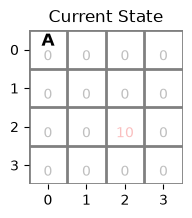

In [70]:
m = Maze()

state_after_bad_action = m.state_transition(m.state, "up")  # Illegal action: bounces!
state_after_good_action = m.state_transition(m.state, "down") # Legal action: Goes down

print("State after illegal action: %s" % (state_after_bad_action,))
print("Reward after illegal action: %s" % (m.reward_transition(m.state, "up", state_after_bad_action)))

print("State after legal action: %s" % (state_after_good_action,))
print("Reward after legal action: %s" % (m.reward_transition(m.state, "down", state_after_good_action)))

fig, ax = plt.subplots(1,1, figsize=(2,2))
im = plot_state(m, ax)

And, finally, we can easily navigate in our virtual maze by executing the appropriate actions:

In [71]:
m.transition("down")

((1, 0), np.float64(0.0))

Note how the ```Maze``` object returns two values at the end of each action execution, the new state $s_{t+1}$ and the associated reward $r_{t+1}$. If the ```down``` action was executed with the original maze layout of the ```grid.txt``` file, the two values are $s_{t+1} = $ ```(1, 0)``` and $r_{t+1} = $ ```0.0```. We can also execute more actions, and see what happens after a few movements:

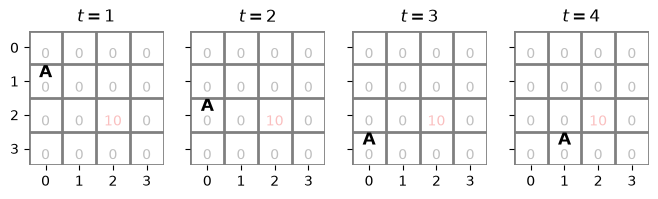

In [72]:
fig, axs = plt.subplots(1,4, figsize=(8,2))

for ax in axs:
    ax.label_outer()
    
plot_state(m, axs[0], title=r"$t=1$")

m.transition("down")
plot_state(m, axs[1], title=r"$t=2$")

m.transition("down")
plot_state(m, axs[2], title=r"$t=3$")

m.transition("right")
plot_state(m, axs[3], title=r"$t=4$")
plt.show()

## Creating a $V$-Agent

Now we can create our own very fantastic agents! As an example, we will create a $V$-learning agent that interacts with the ``` Maze``` world.

The agent contains two parts:

1. The agent's _memory_ is composed of a single $V$-table, which contains  $4 \times 4 = 16$ states, one for every possible position in the maze. 
2. The agent's _policy_ is a simple policy that selects actions _at random_. This guarantees that the agent will explore the environment 

In [73]:
class MazeAgent():
    """An agent that keeps track of the value of states"""
    def __init__(self, actions=Maze.ACTIONS, alpha=0.1, gamma=0.9):
        """Creates a V-agent"""
        self.V = {}                # Initial dictionary of (s, a) pairs. At the beginning, it's empty.
        self.alpha = alpha         # Learning rate
        self.gamma = gamma         # Temporal discounting
        self.actions = actions     # Set of possible actions (provide those of Maze.ACTIONS)


    def policy(self, state):
        """Random policy to explore the maze"""
        return random.choice(self.actions)
        
    
    def td_learning(self, state1, reward2, state2):
        """Updates the Q-values when given an (s,a) pair, the reward value and a new state"""
        g = self.gamma
        a = self.alpha
        
        v1 = 0.0
        
        if state1 in self.V.keys():
            v1 = self.V[state1]
        
        v2 = 0.0
        
        if state2 in self.V.keys():
            v2 = self.V[state2]
        
        rpe = reward2 + g * v2 - v1
        v1 += a * rpe

        self.V[state1] = v1

    
def plot_v_grid(agent, ax=None, title=r"$V$-table", **kwargs):
    "Plots a matrix-like representation of the V-table of an agent"
    if not ax:
        ax = plt.gca()

    data = np.zeros((4,4))            
            
    for s in agent.V.keys():
        x, y = s
        data[x, y] = agent.V[s]
    
    # Plot the heatmap
    im = ax.imshow(data, **kwargs, cmap="viridis")

    # We want to show all ticks...
    ax.set_xticks(np.arange(data.shape[1]))
    ax.set_yticks(np.arange(data.shape[0]))
    ax.set_xticklabels(range(4))
    ax.set_yticklabels(range(4))

    # Let the horizontal axes labeling appear on top.
    ax.tick_params(top=False, bottom=True,
                   labeltop=False, labelbottom=True)

    # Turn spines off and create white grid.
    for edge, spine in ax.spines.items():
        spine.set_visible(False)

    ax.set_xticks(np.arange(data.shape[1]+1)-.5, minor=True)
    ax.set_yticks(np.arange(data.shape[0]+1)-.5, minor=True)
    ax.grid(which="minor", color="grey", linestyle='-', linewidth=2)
    ax.tick_params(which="minor", bottom=False, left=False)
    ax.set_title(title)
    return im

## Interaction Between $V$-Agent and Environment

We need two additional functions to make sure the agent and the environment interact with each other.

In [74]:
def maze_rl_loop(environment, agent):
    """A trial ends when the agent gets a reward. The history is returned"""
    state1 = environment.state
    reward1 = environment.grid[state1[0], state1[1]]
    state2 = "Start"
    
    history = []
    
    while state2 != None:
        action = agent.policy(state1)
        state2, reward2 = environment.transition(action)
        history.append(state2)
        
        # Update the V-values for state1
        agent.td_learning(state1, reward2, state2)
        
        state1 = state2
        reward1 = reward2

    return history

    
def maze_run_trials(environment, agent, n, collect=True):
    """Runs N trials"""
    history = []
    for j in range(n):
        h = maze_rl_loop(environment, agent)
        history += h
        environment.state = Maze.INITIAL_STATE
    
    return history

#### Testing the agent

Now, we can finally test the agent. Note that the cell for the "reward" state is (where the "food" is) remains at zero; this is because the trial actually ends when the agent arrives in the final cell. Because TD-learning methods propagate back in time, another state ("End", for example) would be needed to actually assign the correct value to that cell. 

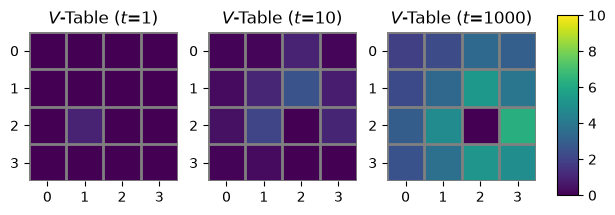

In [75]:
m = Maze()
a = MazeAgent(alpha=0.1)

fig, axs = plt.subplots(1,3, figsize=(7,3))

# Because the agent moves at random, the following instruction can take a variable amount of time to complete
maze_run_trials(m, a, 1)  
#a.visualizeV(axs[0])
plot_v_grid(a, axs[0], vmin=0, vmax=10)
axs[0].set_title(r"$V$-Table ($t$=1)")

maze_run_trials(m, a, 10)
plot_v_grid(a, axs[1], vmin=0, vmax=10)
axs[1].set_title(r"$V$-Table ($t$=10)")

maze_run_trials(m, a, 1000)
im = plot_v_grid(a, axs[2], vmin=0, vmax=10)
axs[2].set_title(r"$V$-Table ($t$=1000)")

#fig.colorbar(im, cax=cbar_ax)
fig.subplots_adjust(right=0.85)
cbar_ax = fig.add_axes([0.88, 0.2, 0.03, 0.6])
fig.colorbar(im, cax=cbar_ax)

## Creating a $Q$-Agent
Now we will create a $Q$-learning agent that interacts with the ```Maze``` world. The $Q$-table should contain $16 \times 4 = 64$ different state-action pairs; rather than filling it up right away, we will fill it up as we encounter new state-action pairs, assuming that any previously unencountered state has a value of $Q = 0$.

The agent below explores with an **$\varepsilon$-greedy** policy: with probability $\varepsilon$ it acts at random, otherwise it takes the action with the highest $Q$-value.

In [76]:
class QAgent():
    def __init__(self, actions=Maze.ACTIONS, epsilon=0.1, 
                 alpha=0.1, gamma=0.9, method="Q-learning"):
        """Creates a Q-agent"""
        self.Q = {}    ## Initial dictionary of (s, a) pairs. At the beginning, it's empty.

        self.epsilon = epsilon     # Epsilon for the epsilon-greedy policy
        self.alpha = alpha         # Learning rate
        self.gamma = gamma         # Temporal discounting
        self.actions = actions     # Set of possible actions (provide those of Maze.ACTIONS)
        self.method = method
        
    def policy(self, state):
        """Selects an action with a epsilon-greedy policy"""
        if random.random() < self.epsilon:
            action = random.choice(self.actions)
        else:
            q = [self.Q[(state, a)] if (state, a) in self.Q.keys() else 0.0 for a in self.actions]
            maxQ = max(q)
            count = q.count(maxQ)
            if count > 1:
                best = [i for i in range(len(self.actions)) if q[i] == maxQ]
                i = random.choice(best)
            else:
                i = q.index(maxQ)

            action = self.actions[i]
        return action

    
    def q_learning(self, state1, action1, reward2, state2):
        """Updates the Q-values when given an (s,a) pair, the reward value and a new state"""
        g = self.gamma
        a = self.alpha
        
        q1 = 0.0
        
        if (state1, action1) in self.Q.keys():
            q1 = self.Q[(state1, action1)]
        
        max_q2 = max([self.Q[(state2, a)] if (state2, a) in self.Q.keys() else 0.0 for a in self.actions])
        
        rpe = reward2 + g * max_q2 - q1
        q1 += a * rpe
        self.Q[(state1, action1)] = q1
        
        
    def sarsa(self, state1, action1, reward2, state2, action2):
        """Updates the Q-values when given an (s,a) pair, the reward value and a new state"""
        g = self.gamma
        a = self.alpha
        
        q1 = 0.0
        q2 = 0.0
        
        if (state1, action1) in self.Q.keys():
            q1 = self.Q[(state1, action1)]
        
        if (state2, action2) in self.Q.keys():
            q2 = self.Q[(state2, action2)]
        
        rpe = reward2 + g * q2 - q1
        q1 += a * rpe
        self.Q[(state1, action1)] = q1
        
    
    def learn(self, state1, action1, reward2, state2, action2):
        "Generic method for learning actions"
        if self.method == "SARSA":
            self.sarsa(state1, action1, reward2, state2, action2)
        elif self.method == "Q-learning":
            self.q_learning(state1, action1, reward2, state2)

## Interactions between $Q$-Agent and Environment

For a $Q$-Agent to work properly, we need to redefine the `maze_rl_loop` function to handle the more complex expression that is needed for $Q$-learning and SARSA.  Because the agent actually _learns_ how to navigate the maze, we can also visualize the agent's preferred paths. 

In [77]:
def maze_rl_loop(environment, agent):
    """A trial ends when the agent gets a reward. The history is returned"""
    state1  = environment.state
    reward1 = environment.grid[state1[0], state1[1]]
    
    action1 = agent.policy(state1)
    
    history = []
    state2  = ""
    
    while state2 != None:
        # Perceive the next step 
        state2, reward2 = environment.transition(action1)
        
        # Save the states visited
        history.append(state1)
        
        # Decide the next action and complete the loop
        action2 = agent.policy(state2)
        
        # Update the Q-values for state1, action1
        agent.learn(state1, action1, reward2, state2, action2)
        
        state1 = state2
        reward1 = reward2
        action1 = action2
        
    return history


def plot_q_table(agent, **kwargs):
    """Visualizes the Q tables, one per action"""
    fig, axs = plt.subplots(2, 2, figsize=(5,5))
    i = 0
    for a in agent.actions:
        # Create the corresponding state table
        data = np.zeros((4,4))
        states = [x for x in agent.Q.keys() if x[1] == a]
            
        for s in states:
            x, y = s[0]
            data[x, y] = agent.Q[s]
        
        # Plot the heatmap
        im = axs.flat[i].imshow(data, **kwargs, cmap="viridis")

        # We want to show all ticks...
        axs.flat[i].set_xticks(np.arange(data.shape[1]))
        axs.flat[i].set_yticks(np.arange(data.shape[0]))
        axs.flat[i].set_xticklabels(range(4))
        axs.flat[i].set_yticklabels(range(4))

        # Let the horizontal axes labeling appear on top.
        axs.flat[i].tick_params(top=False, bottom=True,
                                labeltop=False, labelbottom=True)

        # Turn spines off and create white grid.
        for edge, spine in axs.flat[i].spines.items():
            spine.set_visible(False)

        axs.flat[i].set_xticks(np.arange(data.shape[1]+1)-.5, minor=True)
        axs.flat[i].set_yticks(np.arange(data.shape[0]+1)-.5, minor=True)
        axs.flat[i].grid(which="minor", color="grey", linestyle='-', linewidth=2)
        axs.flat[i].tick_params(which="minor", bottom=False, left=False)
        axs.flat[i].set_title(r"$Q$-values for '%s'" % (a,))

        i += 1
    
    for ax in axs.flat:
        ax.label_outer()

    fig.subplots_adjust(right=0.85, hspace=0.2)
    cbar_ax = fig.add_axes([0.88, 0.2, 0.03, 0.6])
    fig.colorbar(im, cax=cbar_ax)
    #fig.tight_layout()
    
    
def plot_history(history, ax=None, title="History", 
                 cbarlabel="Prop Time Spent", **kwargs):
    if not ax:
        ax = plt.gca()

    data = np.zeros((4,4))            
    for s in history:
        x, y = s
        data[x, y] += 1
    
    data /= np.max(data)
    
    # Plot the heatmap
    im = ax.imshow(data, **kwargs, cmap="Reds")

    # Create colorbar
    cbar = ax.figure.colorbar(im, ax=ax)
    cbar.ax.set_ylabel(cbarlabel, rotation=-90, va="bottom")

    # We want to show all ticks...
    ax.set_xticks(np.arange(data.shape[1]))
    ax.set_yticks(np.arange(data.shape[0]))
    # ... and label them with the respective list entries.
    ax.set_xticklabels(range(4))
    ax.set_yticklabels(range(4))

    # Let the horizontal axes labeling appear on top.
    ax.tick_params(top=False, bottom=True,
                   labeltop=False, labelbottom=True)

    # Turn spines off and create white grid.
    for edge, spine in ax.spines.items():
        spine.set_visible(False)

    ax.set_xticks(np.arange(data.shape[1]+1)-.5, minor=True)
    ax.set_yticks(np.arange(data.shape[0]+1)-.5, minor=True)
    ax.grid(which="minor", color="grey", linestyle='-', linewidth=2)
    ax.tick_params(which="minor", bottom=False, left=False)
    ax.set_title(title)
    return im, cbar


def plot_history_sequence(maze, history, shape=None, **kwargs):
    "Plots a sequence of moves in the grid as a set 'movie' of maze positions"
    N = len(history)
    ncols = 0
    nrows = 0
    if shape is None:
        side = math.ceil(math.sqrt(N))
        if side * (side - 1) > N:
            ncols = side 
            nrows = side - 1
        else:
            ncols = side
            nrows = side
    
    fig, axs = plt.subplots(nrows, ncols, figsize = (ncols * 2, nrows * 2))
    for ax in axs.flatten():
        ax.label_outer()
    for y in range(ncols):
        for x in range(nrows):
            ii = x * ncols + y
            if ii < N:
                plot_state(maze, ax=axs[x, y], position=history[ii], title=r"$t=%d$" % (ii + 1,))
            else:
                axs[x, y].axis('off')
    fig.tight_layout()

## Testing the agent

These are the values saved in the $Q$-table

Text(0.5, 0.98, '$Q$-table after $N=1000$ trials')

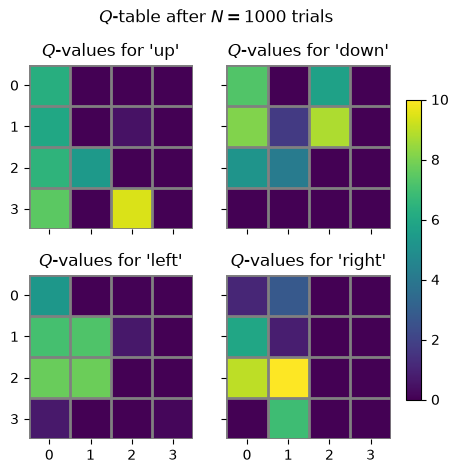

In [78]:
N = 1000
m = Maze()
a = QAgent(epsilon = 0.1, gamma=0.9, alpha=0.1)
maze_run_trials(m, a, N)
plot_q_table(a, vmin=0, vmax=10)
plt.suptitle("$Q$-table after $N=%d$ trials" % (N,))

#### Where does the agent actually go?

Two ways of looking at the same behaviour. `plot_history` collapses many trials into a heatmap of how often each cell was visited. This is the **preferred-path** plot the exercises below ask for. `plot_history_sequence` instead unrolls a *single* trial into one small maze per time step, so you can follow the agent move by move.

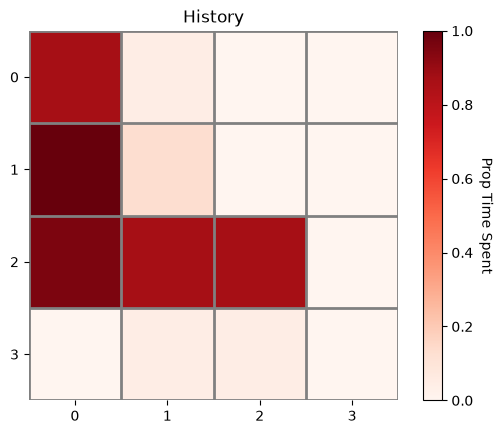

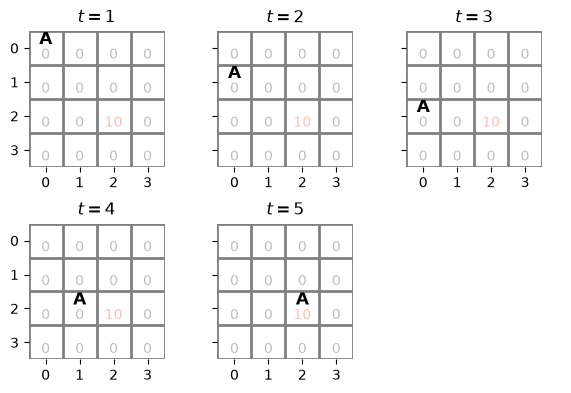

In [79]:
h = maze_run_trials(m, a, 20)
im, cb = plot_history(h)
h = maze_run_trials(m, a, 1)
plot_history_sequence(m, h)

#### How fast is it learning?

Let's see how learning changes the path chosen by the agent over the course of many trials

Text(0.5, 0.98, 'Learning in $Q$-learning')

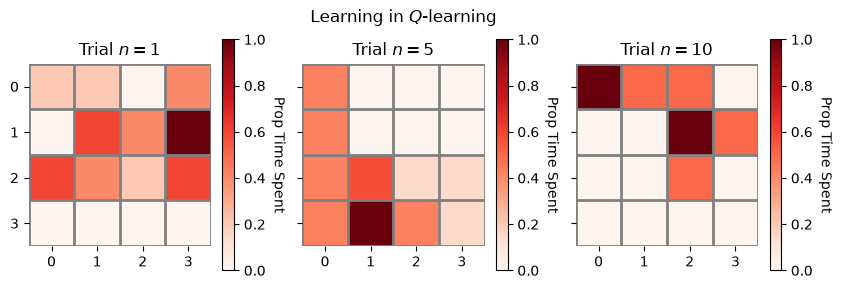

In [80]:
m = Maze()
a = QAgent(epsilon = 0.1)

fig, axs = plt.subplots(1, 3, figsize=(10,3))

for x in axs:
    x.label_outer()

h1 = maze_run_trials(m, a, 1)

maze_run_trials(m, a, 3)
h2 = maze_run_trials(m, a, 1)

maze_run_trials(m, a, 4)
h3 = maze_run_trials(m, a, 1)

plot_history(h1, ax=axs[0], title=r"Trial $n=1$")
plot_history(h2, ax=axs[1], title=r"Trial $n=5$")
plot_history(h3, ax=axs[2], title=r"Trial $n=10$")
fig.suptitle(r"Learning in $Q$-learning")

## Comparing $Q$-learning and SARSA

To compare the two algorithms, namely $Q$-learning and SARSA, let's consider a different type of maze, where the reward is placed behind a "pit" of two negative states, as indicated in ```grid2```. To learn the horrific consequences of falling into the pit, we assign "punishments" ten times as large as the final reward to them. We can visualize the new grid: 

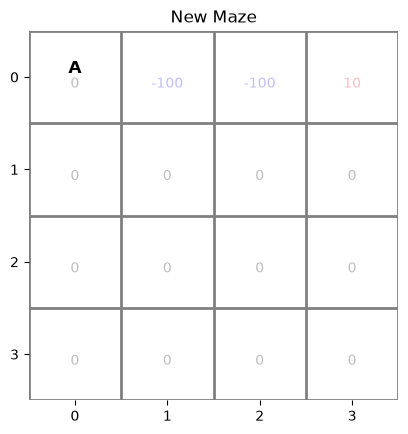

In [81]:
m = Maze("grid2.txt")
plot_state(m, title="New Maze")
plt.show()

### Exercise 2a: Comparing the Paths (2 pts)

Let us first compare the $Q$-values, as well as the preferred paths, after learning to navigate our pit-ridden maze. Both agents run on ```grid2.txt```, the maze plotted just above, and both keep the default parameters ($\varepsilon = 0.1$, $\alpha = 0.1$, $\gamma = 0.9$).

1. Create two `QAgent`s, one with `method="SARSA"` and one with `method="Q-learning"`, and train each for 1000 trials.
2. Plot each agent's $Q$-table with `plot_q_table`. Scale the colours to the agent's own values, `qs = list(agent.Q.values())`, then `plot_q_table(agent, vmin=min(qs), vmax=max(qs))`. The pits drive $Q$-values far below zero, so the `vmin=0` used in the demonstration above would flatten the whole negative half of the table into one colour, and a fixed lower bound such as $-100$ still clips it.
3. Run each trained agent for a further 20 trials, keeping the history that `maze_run_trials` returns, and draw the two visit maps with `plot_history` side by side in one figure.

(<matplotlib.image.AxesImage at 0x137883750>,
 <matplotlib.colorbar.Colorbar at 0x137ce10d0>)

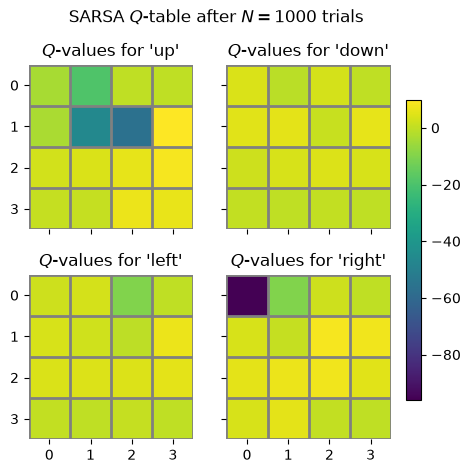

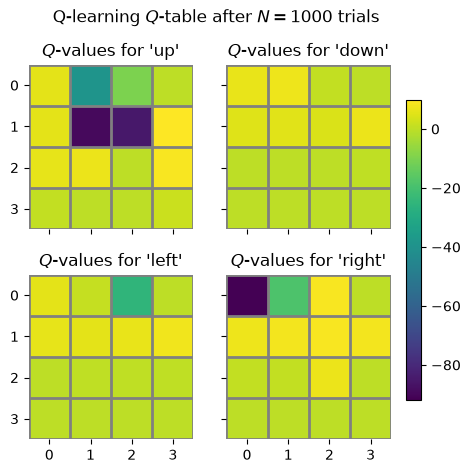

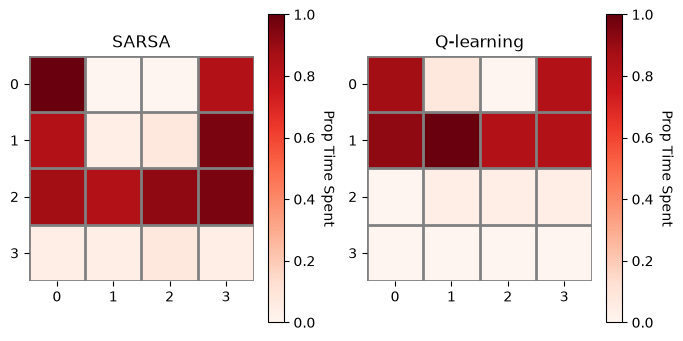

In [82]:
# YOUR CODE HERE
N = 1000
m = Maze("grid2.txt")

# SARSA training (1&2)
sarsa = QAgent(epsilon = 0.1, gamma=0.9, alpha=0.1, method="SARSA")
maze_run_trials(m, sarsa, N)
qs = list(sarsa.Q.values())
plot_q_table(sarsa, vmin=min(qs), vmax=max(qs))
plt.suptitle("SARSA $Q$-table after $N=%d$ trials" % (N,))

# Q-learning training (1&2)
qlearn = QAgent(epsilon = 0.1, gamma=0.9, alpha=0.1, method="Q-learning")
maze_run_trials(m, qlearn, N)
qs = list(qlearn.Q.values())
plot_q_table(qlearn, vmin=min(qs), vmax=max(qs))
plt.suptitle("Q-learning $Q$-table after $N=%d$ trials" % (N,))

# SARSA & Q-learning further trials plus maps (3)
sarsa_further = maze_run_trials(m, sarsa, 20)
qlearn_further = maze_run_trials(m, qlearn, 20)

fig, axs = plt.subplots(1, 2, figsize=(8, 4))
plot_history(sarsa_further, axs[0], "SARSA")
plot_history(qlearn_further, axs[1], "Q-learning")

### Exercise 2b: Interpret! (2 pts)

Compare the preferred paths, and, if helpful, the Q-values of both methods to one another! What paths does each of them take? How do they differ? Can you explain why the preferred paths differ, based on your knowledge of the two algorithms? What are the respective advantages and disadvantages resulting from each method?

*Answer (2b):* The SARSA method entirely tries to avoid the pits, it strays far away from the closest tiles to the pits and takes a longer route whilst the Q-learning method takes the shortest possible path. 

### Exercise 3a: Wand$\varepsilon$rlust (2 pts)

Repeat Exercise 2a on the same maze, ```grid2.txt```, but make both agents highly curious explorers by setting $\varepsilon = 0.5$ instead of the default $0.1$. Leave $\alpha$ and $\gamma$ at their defaults.

1. Create two `QAgent`s with `epsilon=0.5`, one SARSA and one Q-learning, and train each for 1000 trials.
2. Plot each agent's $Q$-table with `plot_q_table`, scaled to the agent's own $Q$-values as in Exercise 2a.
3. Run each trained agent for a further 20 trials and draw the two visit maps side by side in one figure.

(<matplotlib.image.AxesImage at 0x168591a50>,
 <matplotlib.colorbar.Colorbar at 0x1685ed990>)

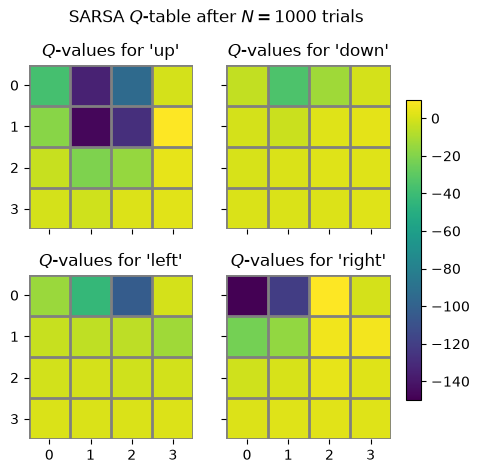

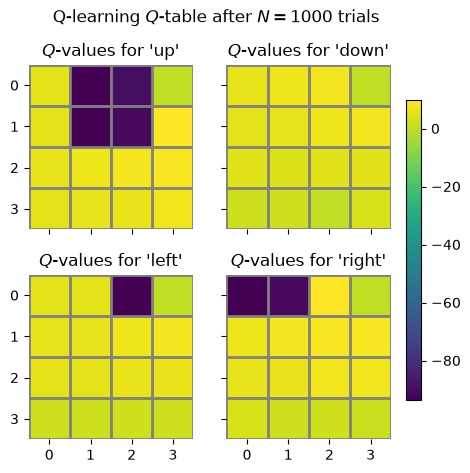

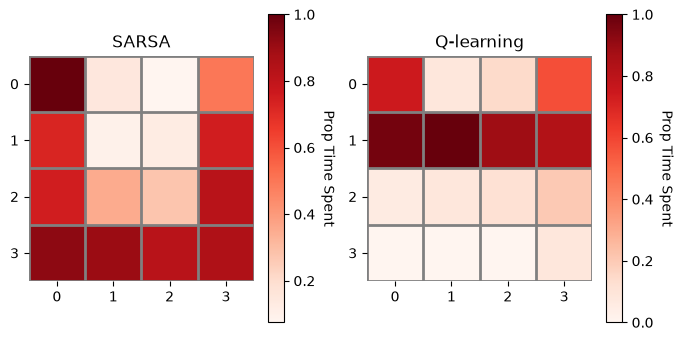

In [83]:
# YOUR CODE HERE
N = 1000
m = Maze("grid2.txt")

# SARSA training (1&2)
sarsa = QAgent(epsilon = 0.5, gamma=0.9, alpha=0.1, method="SARSA")
maze_run_trials(m, sarsa, N)
qs = list(sarsa.Q.values())
plot_q_table(sarsa, vmin=min(qs), vmax=max(qs))
plt.suptitle("SARSA $Q$-table after $N=%d$ trials" % (N,))

# Q-learning training (1&2)
qlearn = QAgent(epsilon = 0.5, gamma=0.9, alpha=0.1, method="Q-learning")
maze_run_trials(m, qlearn, N)
qs = list(qlearn.Q.values())
plot_q_table(qlearn, vmin=min(qs), vmax=max(qs))
plt.suptitle("Q-learning $Q$-table after $N=%d$ trials" % (N,))

# SARSA & Q-learning further trials plus maps (3)
sarsa_further = maze_run_trials(m, sarsa, 20)
qlearn_further = maze_run_trials(m, qlearn, 20)

fig, axs = plt.subplots(1, 2, figsize=(8, 4))
plot_history(sarsa_further, axs[0], "SARSA")
plot_history(qlearn_further, axs[1], "Q-learning")

### Exercise 3b: Interpret! (2 pts)

Explain what is happening in both cases! (How) do the respective Q values and preferred paths change at higher epsilon values. If there is a change for both, can you explain why this change is happening, and what the agent is effectively "trying to achieve" based on its algorithm? If there is no, or relatively little change, what "protects" the respective algorithm?

*Answer (3b)*: The models this time want to explore the grid further. The more the SARSA method explores, the less riskier paths it finds, thus, this time it takes an even longer path than in 2a. Meanwhile, the Q-learning method also explores less risky paths but its preferred path remains the riskier but shorter path. 

### Exercise 4a: $Q$-tting Corners (1 pt)

We will now introduce a new Maze with a direct route, effectively a shortcut, towards the reward. However, there is a pit directly next to it, making it quite risky to fall into the pit! You can see the Maze, ```grid3``` below.

Train the two agents on the new grid, as you did in Exercise 2a.

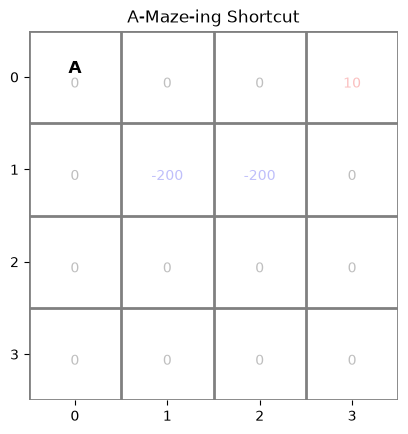

In [84]:
m = Maze("grid3.txt")
plot_state(m, title="A-Maze-ing Shortcut")
plt.show()

(<matplotlib.image.AxesImage at 0x168503d90>,
 <matplotlib.colorbar.Colorbar at 0x1683de4d0>)

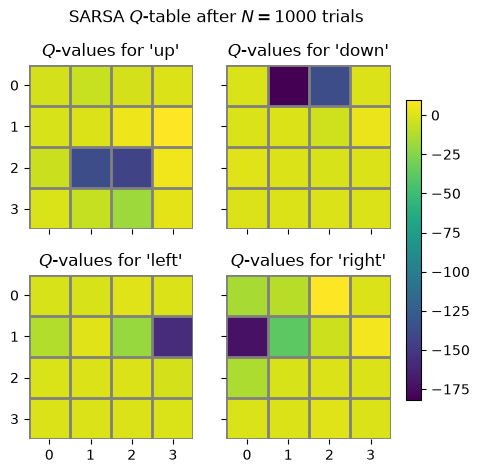

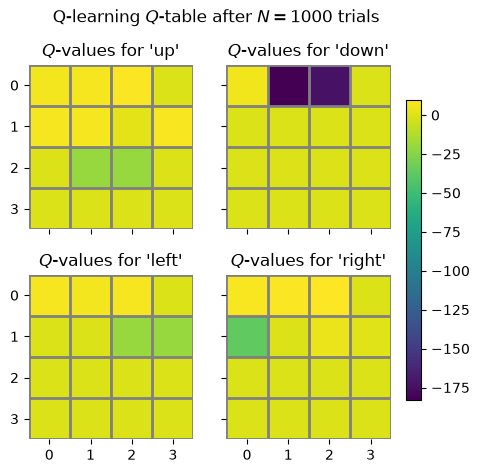

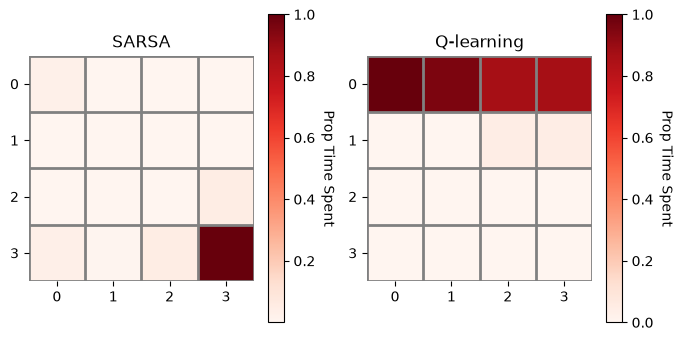

In [85]:
# YOUR CODE HERE
N = 1000
m = Maze("grid3.txt")

# SARSA training (1&2)
sarsa = QAgent(epsilon = 0.1, gamma=0.9, alpha=0.1, method="SARSA")
maze_run_trials(m, sarsa, N)
qs = list(sarsa.Q.values())
plot_q_table(sarsa, vmin=min(qs), vmax=max(qs))
plt.suptitle("SARSA $Q$-table after $N=%d$ trials" % (N,))

# Q-learning training (1&2)
qlearn = QAgent(epsilon = 0.1, gamma=0.9, alpha=0.1, method="Q-learning")
maze_run_trials(m, qlearn, N)
qs = list(qlearn.Q.values())
plot_q_table(qlearn, vmin=min(qs), vmax=max(qs))
plt.suptitle("Q-learning $Q$-table after $N=%d$ trials" % (N,))

# SARSA & Q-learning further trials plus maps (3)
sarsa_further = maze_run_trials(m, sarsa, 20)
qlearn_further = maze_run_trials(m, qlearn, 20)

fig, axs = plt.subplots(1, 2, figsize=(8, 4))
plot_history(sarsa_further, axs[0], "SARSA")
plot_history(qlearn_further, axs[1], "Q-learning")

### Exercise 4b: Interpret! (3 pts)

How do the preferred paths of $Q$-Learning and SARSA look respectively? Why? If there is one which leads to a rather "weird"-looking result, why does the algorithm lead to this behavior, and what has it effectively learned?

*Answer (4b):* The SARSA method has a very weird looking result. This is because in its search for the least risky path, this method almost entirely ends up avoiding the path that leads to the goal. SARSA doesn't even really take the straight line pathm it avoids it because all the tiles on the straight line path are adjacent to the pit tiles. However, Q-learning is again very risky, and ends up taking the shortest, riskiest, straight line path and reaches the goal.

### Exercise 4c: On a better path! (2 pts)

Which parameter do you need to adjust for the "weird" agent to settle on a "proper" path towards the reward. Implement the change and rerun **both** agents on ```grid3.txt```, plotting them as you did in Exercise 4a. The point of keeping the other agent is that its behaviour under the same change is part of your evidence. Then briefly explain which parameter you changed, how, and why this led to the desired outcome.

(<matplotlib.image.AxesImage at 0x137e28d90>,
 <matplotlib.colorbar.Colorbar at 0x1683cd990>)

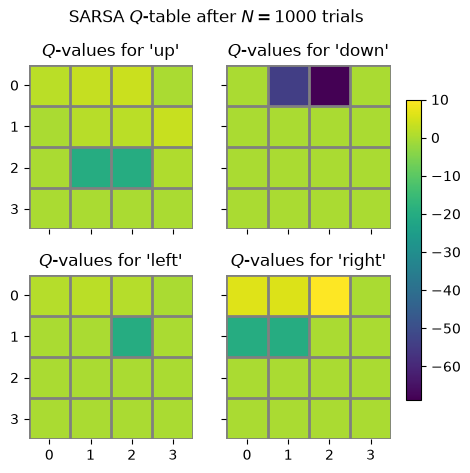

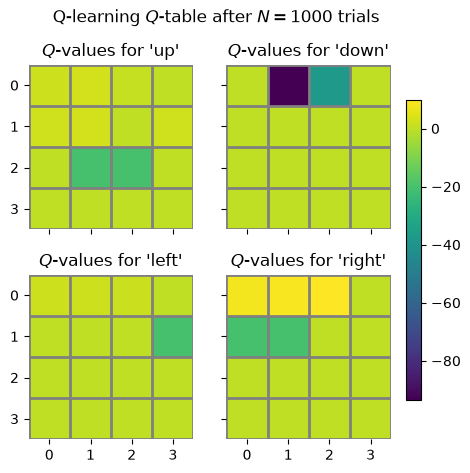

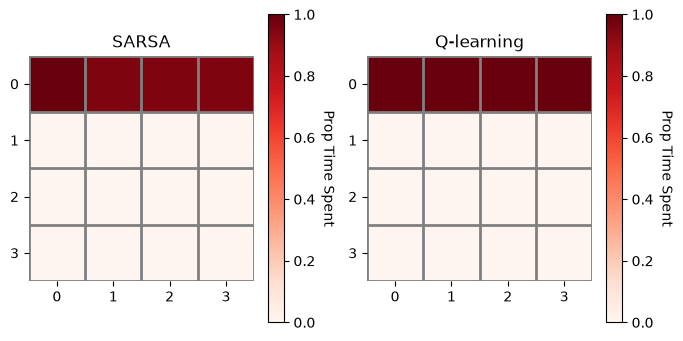

In [86]:
# YOUR CODE HERE
N = 1000
m = Maze("grid3.txt")

# SARSA training (1&2)
sarsa = QAgent(epsilon = 0.01, gamma=0.9, alpha=0.1, method="SARSA")
maze_run_trials(m, sarsa, N)
qs = list(sarsa.Q.values())
plot_q_table(sarsa, vmin=min(qs), vmax=max(qs))
plt.suptitle("SARSA $Q$-table after $N=%d$ trials" % (N,))

# Q-learning training (1&2)
qlearn = QAgent(epsilon = 0.01, gamma=0.9, alpha=0.1, method="Q-learning")
maze_run_trials(m, qlearn, N)
qs = list(qlearn.Q.values())
plot_q_table(qlearn, vmin=min(qs), vmax=max(qs))
plt.suptitle("Q-learning $Q$-table after $N=%d$ trials" % (N,))

# SARSA & Q-learning further trials plus maps (3)
sarsa_further = maze_run_trials(m, sarsa, 20)
qlearn_further = maze_run_trials(m, qlearn, 20)

fig, axs = plt.subplots(1, 2, figsize=(8, 4))
plot_history(sarsa_further, axs[0], "SARSA")
plot_history(qlearn_further, axs[1], "Q-learning")

*Answer (4c):* Changing the epsilon value leads to less exploratory paths being taken, I tried decreasing the SARSA epsilon value from 0.1 down to 0.01 and that made it avoid exploring and take the straight line path that leads directly to the goal. The agent is now much less likely to take a random action near the pit, which is exactly what we wanted. 

### Exercise 4d: Environmentalism (1 pt)

If the agents were simply too stubborn to change their parameters, is there something you could change about the maze/grid/environment which would, in principle, help solving the issue shown in 4a? Both the reward and the pits have to stay. You do NOT have to actually implement and test it!

*Answer (4d):* If we were to move the pits so that they were much farther away from the goal, the SARSA method would also be more inclined to pick the straight line path to the goal because the risk would be moved. This would make it so that both models take thr shortest possible path for the grid. 